# **Deep Pricing: Estimating S&P 500 Options Pricing using Deep Learning**
**Course:** AI in Finance (Mohamed El Fakir & Nicolas de Roux)  
**Task:** Supervised Learning (Regression) replacing traditional econometric models.

## 1. Setup and Library Imports
In this section, we import the necessary libraries for our data science pipeline. We use `pandas` and `numpy` for data manipulation, `scikit-learn` for preprocessing and evaluation, and `PyTorch` for building our Deep Learning architecture. We also mount Google Drive to access our massive historical dataset.

In [ ]:
# ==============================================================================
# Setup and Imports (Configuration et Importation des Bibliothèques)
# ==============================================================================

# 1. OUTILS DE MANIPULATION DES DONNÉES (Le "moteur" de traitement)
import pandas as pd  # Pandas : Indispensable pour lire le gros fichier CSV et créer des "DataFrames" (tableaux virtuels).
import numpy as np   # Numpy : Spécialiste des calculs mathématiques rapides sur des matrices (racines, log, etc.).

# 2. OUTILS DE VISUALISATION (Pour créer les graphiques)
import matplotlib.pyplot as plt  # Matplotlib : L'outil de base pour tracer des courbes et des nuages de points.
import seaborn as sns            # Seaborn : Rend les graphiques de Matplotlib beaucoup plus beaux et professionnels.

# 3. OUTILS DE MACHINE LEARNING CLASSIQUE (Scikit-Learn)
from sklearn.model_selection import train_test_split # Pour couper nos données en deux : "Train" (Apprentissage) et "Test" (Vérification).
from sklearn.preprocessing import StandardScaler     # Pour "Normaliser" les données : met toutes les valeurs à la même échelle pour aider l'IA.

# 4. OUTILS DE DEEP LEARNING (L'Intelligence Artificielle de Meta/Facebook)
# Note : PyTorch est très utilisé dans la recherche quantitative financière (Quantitative Finance).
import torch             # Cœur de PyTorch.
import torch.nn as nn    # Neural Networks : Contient les briques (couches, neurones) pour construire le cerveau de l'IA.
import torch.optim as optim # Optimizers : Contient les algorithmes (ex: Adam) qui permettent à l'IA de corriger ses erreurs (rétropropagation).

# 5. CONNEXION AU CLOUD (Spécifique à Google Colab)
# Permet à ce script Python d'accéder à tes fichiers personnels stockés sur ton Google Drive.
from google.colab import drive
drive.mount('/content/drive')

# Message de confirmation pour vérifier que la cellule s'est bien exécutée
print("Libraries imported and Drive mounted successfully!")

Mounted at /content/drive
Libraries imported and Drive mounted successfully!


In [ ]:
# ==============================================================================
# Connexion à Google Drive
# ==============================================================================

# Importe le module 'drive' depuis la bibliothèque spécifique à Google Colab.
# Ce module sert de pont entre l'environnement d'exécution (la machine virtuelle) et tes fichiers.
from google.colab import drive

# L'argument '/content/drive' définit le chemin d'accès (le dossier) où tes fichiers apparaîtront.
# Lors de l'exécution, Colab demandera une autorisation d'accès via une fenêtre pop-up.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Ingestion
Options chain datasets are notoriously large. Here, we load 3 years of daily S&P 500 ($SPY) options data (2020-2022). This specific timeframe was chosen because it encompasses extreme market events (the COVID-19 crash and the 2022 inflation bear market), providing the extreme volatility needed to test our neural network against traditional models. We load this via `pandas` with memory optimization.

In [ ]:
# ==============================================================================
# Chargement et Inspection du Jeu de Données (Kaggle Dataset)
# ==============================================================================

import pandas as pd

# 1. Définition du chemin d'accès au fichier
# Ce chemin pointe vers le répertoire de votre Google Drive monté lors de la Cellule 1.
file_path = '/content/drive/MyDrive/AI_Finance_Project/spy_2020_2022.csv'

# 2. Chargement du jeu de données en mémoire vive (RAM)
print("Loading massive dataset into memory. This might take a minute...")

# Lecture du fichier CSV pour créer un objet DataFrame Pandas (options_df).
# L'argument `low_memory=False` est crucial pour le Big Data : il force Pandas à lire
# le fichier d'un seul bloc (ou à allouer plus de mémoire) pour inférer correctement
# le type des données (int, float, string) et éviter les alertes de types mixtes (DtypeWarning).
options_df = pd.read_csv(file_path, low_memory=False)

# 3. Inspection de la dimensionnalité du jeu de données
print("\n--- Dataset Info ---")
# La propriété .shape retourne un tuple (lignes, colonnes).
# Le formatage {:,} ajoute des séparateurs de milliers pour faciliter la lecture.
print(f"Total Rows: {options_df.shape[0]:,}")
print(f"Total Columns: {options_df.shape[1]}")

print("\n--- Column Names ---")
# Affiche la liste complète des caractéristiques (features) brutes disponibles.
print(list(options_df.columns))

# 4. Aperçu de la structure des données brutes
print("\n--- First 5 Rows ---")
# La méthode .head() retourne les 5 premières lignes.
# La fonction display() est spécifique aux notebooks (Jupyter/Colab) pour un rendu HTML lisible.
display(options_df.head())

Loading massive dataset into memory. This might take a minute...

--- Dataset Info ---
Total Rows: 3,589,079
Total Columns: 33

--- Column Names ---
['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]', ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]', ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]', ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]', ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]', ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]', ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]', ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]']

--- First 5 Rows ---


,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


## 3. Data Cleaning and Feature Engineering
Financial data is often messy and requires strict preprocessing before it can be fed into a machine learning model. This step mirrors the Data Science pipeline taught in Course 2 & 3.

**Key Preprocessing Steps:**
* **Type Conversion:** Forcing string-formatted bid/ask prices into numeric floats.
* **Target Variable:** Calculating the `Option_Price` as the midpoint between the Bid and Ask.
* **Filtering:** Removing illiquid options (Volume = 0) and options expiring today (DTE = 0) to remove microstructure noise.
* **Sampling:** Downsampling to 200,000 highly liquid contracts to allow the PyTorch model to train within memory constraints.

In [ ]:
# ==============================================================================
# Data Cleaning and Structuring (Nettoyage et Ingénierie des Données)
# ==============================================================================
import pandas as pd
import numpy as np

print("1. Cleaning column names...")
# Les datasets bruts (surtout sur Kaggle) ont souvent des noms de colonnes mal formatés (ex: "[C_BID] ").
# Cette ligne utilise une expression régulière (regex) pour supprimer les espaces et les crochets.
# Ça évite des bugs plus tard quand on appellera les colonnes.
options_df.columns = options_df.columns.str.replace(r'[ \[\]]', '', regex=True)

print("2. Converting columns to numbers (Fixing the TypeError)...")
# Parfois, un fichier CSV contient une virgule ou un espace caché dans un chiffre,
# ce qui force Pandas à lire toute la colonne comme du "Texte" (String) au lieu de "Nombres" (Float).
cols_to_convert = ['UNDERLYING_LAST', 'DTE', 'STRIKE', 'C_BID', 'C_ASK', 'C_VOLUME', 'C_IV', 'P_BID', 'P_ASK', 'P_VOLUME', 'P_IV']
for col in cols_to_convert:
    # L'argument 'errors=coerce' est magique : si Pandas croise du texte impossible à convertir
    # en nombre, il ne fait pas crasher le code, il remplace juste la case par 'NaN' (Not a Number).
    options_df[col] = pd.to_numeric(options_df[col], errors='coerce')

print("3. Splitting Calls and Puts into separate rows...")
# LE PROBLÈME : Les données brutes sont "larges" (Infos du Call à gauche, Infos du Put à droite sur la même ligne).
# L'OBJECTIF : Les réseaux de neurones ont besoin de données "longues" (1 ligne = 1 seule option).

# On définit les colonnes communes (Date, Prix de l'action, Jours avant expiration, Strike).
base_cols = ['QUOTE_DATE', 'UNDERLYING_LAST', 'DTE', 'STRIKE']

# On isole toutes les options d'achat (CALLS) et on renomme leurs colonnes pour qu'elles soient génériques.
calls = options_df[base_cols + ['C_BID', 'C_ASK', 'C_VOLUME', 'C_IV']].copy()
calls.rename(columns={'C_BID': 'BID', 'C_ASK': 'ASK', 'C_VOLUME': 'VOLUME', 'C_IV': 'IV'}, inplace=True)
calls['Is_Call'] = 1 # Création d'une variable binaire : 1 = Call (Feature Engineering)

# On fait exactement la même chose pour les options de vente (PUTS).
puts = options_df[base_cols + ['P_BID', 'P_ASK', 'P_VOLUME', 'P_IV']].copy()
puts.rename(columns={'P_BID': 'BID', 'P_ASK': 'ASK', 'P_VOLUME': 'VOLUME', 'P_IV': 'IV'}, inplace=True)
puts['Is_Call'] = 0 # 0 = Put

# On empile les Calls et les Puts les uns sur les autres pour créer un seul grand dataset propre.
df_clean = pd.concat([calls, puts], ignore_index=True)

# OPTIMISATION DE LA MÉMOIRE : On supprime les vieux tableaux pour vider la RAM de Google Colab.
del options_df
del calls
del puts

print("4. Calculating Option Price & Filtering Data...")
# LA VARIABLE CIBLE (TARGET) : En finance, le dernier prix échangé est souvent faussé par le "bruit" du marché.
# On calcule le prix médian (Midpoint) entre l'offre (Bid) et la demande (Ask) comme "Juste Prix".
df_clean['Option_Price'] = (df_clean['BID'] + df_clean['ASK']) / 2

# FILTRE 1 : Liquidité. Si le volume est de 0, personne n'a tradé. Le prix affiché est un "prix fantôme" (stale price). On jette.
df_clean = df_clean[df_clean['VOLUME'] > 0]

# FILTRE 2 : Bruit à l'échéance. Les options qui expirent le jour même (0-DTE) ont des prix très instables
# et ne suivent plus les lois mathématiques normales (Gamma très élevé). On les exclut.
df_clean = df_clean[df_clean['DTE'] > 0]

# FILTRE 3 : Nettoyage final. On supprime les lignes où il manque des données ('NaN').
df_clean = df_clean.dropna(subset=['IV', 'BID', 'ASK'])

print(f"Total valid traded contracts: {df_clean.shape[0]:,}")

print("5. Sampling 200,000 rows for Neural Network training...")
# CONTRAINTE TECHNIQUE : 3,5 millions de lignes, c'est trop gros pour la RAM gratuite de Colab
# et ça mettrait des heures à s'entraîner.
# On extrait donc un échantillon aléatoire représentatif de 200 000 lignes (suffisant pour le Deep Learning).
# 'random_state=42' garantit que l'on tire exactement les mêmes 200 000 lignes à chaque fois qu'on lance le code.
df_sampled = df_clean.sample(n=200000, random_state=42)

# Sélection finale : On ne garde que les "Features" (Inputs de l'IA) et le "Target" (Ce qu'on veut prédire).
features = ['UNDERLYING_LAST', 'STRIKE', 'DTE', 'IV', 'Is_Call']
target = 'Option_Price'

final_data = df_sampled[features + [target]].copy()

print("\n--- Final Cleaned Data for Machine Learning ---")
display(final_data.head())

1. Cleaning column names...
2. Converting columns to numbers (Fixing the TypeError)...
3. Splitting Calls and Puts into separate rows...
4. Calculating Option Price & Filtering Data...
Total valid traded contracts: 3,991,447
5. Sampling 200,000 rows for Neural Network training...

--- Final Cleaned Data for Machine Learning ---


,UNDERLYING_LAST,STRIKE,DTE,IV,Is_Call,Option_Price
6553778,419.20,373.0,34.00,0.25241,0,0.915
4046786,338.44,271.0,67.04,0.37149,0,1.920
1410731,319.03,257.0,72.00,0.37947,1,63.390
4600762,389.81,230.0,280.00,0.41535,0,3.285
43909,444.19,475.0,185.00,0.14300,1,6.545


## 3.5 Exploratory Data Analysis (EDA)
Before modeling, it is crucial to understand the underlying distributions and mathematical relationships within our cleaned dataset.
* **The Correlation Heatmap** allows us to verify that our features have meaningful linear (or inverse) relationships with the target `Option_Price`.
* **The Distribution Plot** helps us identify skewness in the pricing data, which is typical in financial markets where most traded options are relatively cheap, with a long "fat tail" of expensive deep-in-the-money contracts.

Generating Exploratory Data Analysis (EDA) plots...


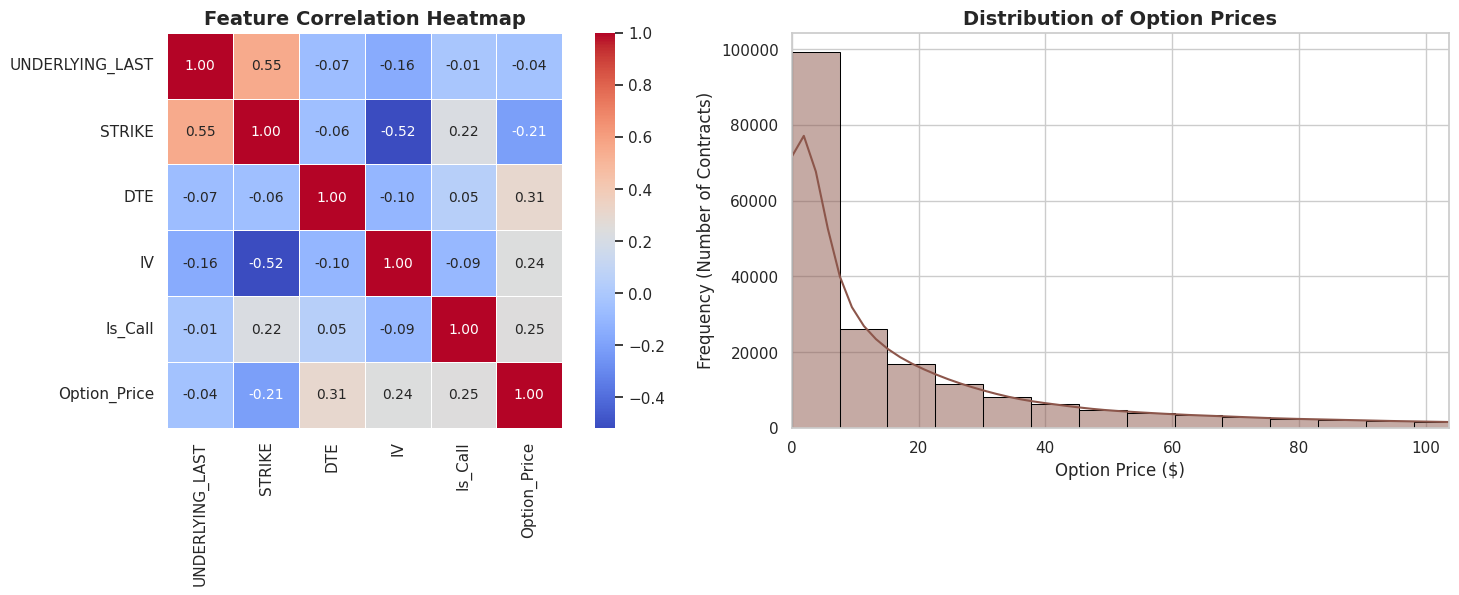

In [ ]:
# ==============================================================================
# Exploratory Data Analysis (EDA) - Visualisation des données
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique
sns.set_theme(style="whitegrid") # Ajoute une grille de fond claire
plt.rcParams.update({'font.size': 10}) # Uniformise la taille de la police

print("Generating Exploratory Data Analysis (EDA) plots...")

# Création d'une "Figure" (la toile de fond) divisée en 2 "Axes" (les sous-graphiques)
# 1 ligne, 2 colonnes, taille totale de 16x6 pouces.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------------------
# GRAPH 1: Correlation Heatmap (Matrice de Corrélation)
# ------------------------------------------------------------------------------
# Objectif : Vérifier si nos variables ne sont pas "trop" corrélées entre elles (multicolinéarité)
# et voir lesquelles ont le plus d'impact direct sur le prix.
corr_matrix = final_data.corr()

# Création de la carte de chaleur (Heatmap)
# annot=True : affiche les chiffres exacts dans les cases.
# cmap="coolwarm" : utilise un code couleur intuitif (Rouge = forte corrélation positive, Bleu = négative)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            cbar=True, square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# ------------------------------------------------------------------------------
# GRAPH 2: Distribution of Option Prices (Histogramme des Prix)
# ------------------------------------------------------------------------------
# Objectif : Regarder la forme statistique de notre variable cible (Target).
# Les prix financiers suivent rarement une courbe en cloche parfaite (loi normale).
sns.histplot(final_data['Option_Price'], bins=50, color='#8c564b',
             kde=True, edgecolor='black', ax=axes[1]) # kde=True dessine la courbe de tendance lissée

axes[1].set_title('Distribution of Option Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Option Price ($)', fontsize=12)
axes[1].set_ylabel('Frequency (Number of Contracts)', fontsize=12)

# ASTUCE DE DATA SCIENTIST : Le filtrage des valeurs extrêmes (Outliers) visuels
# Le marché des options contient quelques contrats extrêmement chers qui écrasent le graphique.
# En limitant l'axe X au 95ème centile (quantile 0.95), on zoome sur là où se trouvent 95% des données,
# ce qui rend le graphique beaucoup plus lisible pour la présentation.
axes[1].set_xlim(0, final_data['Option_Price'].quantile(0.95))

# plt.tight_layout() ajuste automatiquement les marges pour que les titres ne se chevauchent pas.
plt.tight_layout()
plt.show()

## 4. Traditional Finance Baseline: The Black-Scholes Model
Before evaluating an AI, we must establish a traditional econometric baseline. We define the classic Black-Scholes-Merton mathematical formula to calculate the theoretical price of our options. We then compare this theoretical price to the *actual* market price to calculate our baseline Mean Absolute Error (MAE).

*Note: SPY options are American, while Black-Scholes is designed for European options. This theoretical limitation is exactly what we expect our Deep Learning model to overcome.*

In [ ]:
# ==============================================================================
# Le Modèle de Référence (Baseline) - Formule de Black-Scholes
# ==============================================================================
import numpy as np
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("1. Defining the Black-Scholes Mathematical Formula...")

def black_scholes(S, K, T, r, sigma, is_call):
    """
    Implémentation vectorisée du modèle de tarification des options de Black-Scholes.

    Paramètres :
    S (Spot)   : Prix actuel du sous-jacent (UNDERLYING_LAST)
    K (Strike) : Prix d'exercice de l'option
    T (Time)   : Temps avant échéance exprimé en années (DTE / 365)
    r (Rate)   : Taux d'intérêt sans risque annualisé
    sigma (IV) : Volatilité implicite
    is_call    : Variable binaire (1 pour un Call, 0 pour un Put)
    """
    # SÉCURITÉ MATHÉMATIQUE : On remplace les 0 stricts par une valeur infinitésimale (1e-5)
    # Cela empêche le code de crasher (division par zéro) si une option expire aujourd'hui
    # ou si la volatilité est exceptionnellement nulle.
    T = np.maximum(T, 1e-5)
    sigma = np.maximum(sigma, 1e-5)

    # Calcul de d1 et d2 : Les paramètres de diffusion de l'équation différentielle stochastique
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Application des fonctions de répartition de la loi normale (norm.cdf)
    # Calcul théorique du prix d'un Call européen
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    # Calcul théorique du prix d'un Put européen
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    # OPTIMISATION VECTORIELLE : Au lieu de faire une boucle 'for' lente ligne par ligne,
    # np.where applique la condition sur tout le dataset instantanément.
    # Si is_call == 1, on assigne le call_price, sinon on assigne le put_price.
    return np.where(is_call == 1, call_price, put_price)

print("2. Calculating Theoretical Prices for our dataset...")

# HYPOTHÈSE DU TAUX SANS RISQUE : Nous fixons un taux moyen approximatif de 1,5% (0.015)
# représentatif de la période 2020-2022 (avant les fortes hausses de la FED).
RISK_FREE_RATE = 0.015

# Création d'une nouvelle colonne 'BS_Price' contenant le prix théorique mathématique.
# Note : Le DTE (Days to Expiration) est divisé par 365 pour l'annualiser, comme l'exige la formule.
final_data['BS_Price'] = black_scholes(
    S=final_data['UNDERLYING_LAST'].values,
    K=final_data['STRIKE'].values,
    T=final_data['DTE'].values / 365.0,
    r=RISK_FREE_RATE,
    sigma=final_data['IV'].values,
    is_call=final_data['Is_Call'].values
)

print("3. Evaluating the Baseline Model...")

# Évaluation des performances du modèle mathématique par rapport à la réalité du marché
mse_bs = mean_squared_error(final_data['Option_Price'], final_data['BS_Price'])
mae_bs = mean_absolute_error(final_data['Option_Price'], final_data['BS_Price'])

# Affichage du score à battre pour l'Intelligence Artificielle
print(f"--> Black-Scholes Mean Squared Error (MSE): {mse_bs:.4f}")
print(f"--> Black-Scholes Mean Absolute Error (MAE): ${mae_bs:.4f}")

print("\n--- Comparing Actual Price vs Black-Scholes Price ---")
# Affichage d'un échantillon pour comparer visuellement la précision de la formule
display(final_data[['Option_Price', 'BS_Price', 'UNDERLYING_LAST', 'STRIKE', 'Is_Call']].head(10))

1. Defining the Black-Scholes Mathematical Formula...
2. Calculating Theoretical Prices for our dataset...
3. Evaluating the Baseline Model...
--> Black-Scholes Mean Squared Error (MSE): 8.9048
--> Black-Scholes Mean Absolute Error (MAE): $1.4764

--- Comparing Actual Price vs Black-Scholes Price ---


,Option_Price,BS_Price,UNDERLYING_LAST,STRIKE,Is_Call
6553778,0.915,0.824976,419.20,373.0,0
4046786,1.920,1.711275,338.44,271.0,0
1410731,63.390,64.975928,319.03,257.0,1
4600762,3.285,3.268287,389.81,230.0,0
43909,6.545,8.058034,444.19,475.0,1
6282698,0.175,0.152342,425.33,240.0,0
681363,3.290,4.897647,294.84,377.0,1
4644399,5.110,4.693903,380.72,382.5,0
4831643,32.415,30.690064,273.11,287.0,0
4431816,1.095,1.125270,377.96,255.0,0


## 5. Deep Learning Approach: Multi-Layer Perceptron (MLP)
In this section, we apply the Deep Learning concepts from Course 6 to predict the option premium.

* **Scaling:** We use `StandardScaler` on inputs like Strike Price and Volatility. This is critical to prevent exploding gradients during backpropagation.
* **Architecture:** A 3-hidden-layer feedforward neural network using ReLU activations.
* **Training:** We train the model over 30 epochs using the Adam optimizer, minimizing the Mean Squared Error (MSE) loss function.

In [ ]:
# ==============================================================================
# Cell 5: Deep Learning Model (PyTorch) - Architecture Classique
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("1. Preparing Data for Deep Learning...")

# 1. SÉLECTION DES VARIABLES
# Features (X) : Les 5 variables que l'IA va regarder pour prendre sa décision.
# Target (y) : La réponse qu'elle doit deviner (le prix de l'option).
features = ['UNDERLYING_LAST', 'STRIKE', 'DTE', 'IV', 'Is_Call']
X = final_data[features].values
y = final_data['Option_Price'].values

# 2. SÉPARATION EN TRAIN / TEST
# On entraîne l'IA sur 80% des données (Train) et on la teste sur 20% (Test) qu'elle n'a jamais vus.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. NORMALISATION DES DONNÉES (Feature Scaling) - Étape très importante !
# Les réseaux de neurones sont perdus si on mélange des gros chiffres (Strike à 4000)
# et des petits chiffres (IV à 0.15). Le Scaler met tout sur la même échelle (moyenne 0, variance 1).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Apprend l'échelle sur le Train
X_test_scaled = scaler.transform(X_test)       # Applique la même échelle au Test

# 4. CONVERSION EN TENSEURS PYTORCH
# PyTorch utilise des "Tenseurs" (des matrices mathématiques ultra-rapides) au lieu de tableaux Numpy.
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1) # .view(-1, 1) force le format en une colonne verticale
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# 5. CRÉATION DES BATCHS (DataLoaders)
# Plutôt que de donner 160 000 lignes d'un coup à l'IA, on les lui donne par paquets de 512.
# Cela rend l'apprentissage beaucoup plus stable et évite de saturer la mémoire (RAM).
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True) # On mélange les données à chaque passage

print("2. Defining the Neural Network Architecture...")

# --- DÉFINITION DU CERVEAU DE L'IA ---
class OptionPricingNN(nn.Module):
    def __init__(self):
        super(OptionPricingNN, self).__init__()
        # Couche d'entrée : Reçoit les 5 variables (Features) et les envoie vers 64 neurones
        self.layer1 = nn.Linear(5, 64)
        self.relu1 = nn.ReLU() # Fonction d'activation (laisse passer le signal s'il est utile)

        # Couche cachée 1 : 64 neurones se connectent à 32 neurones
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()

        # Couche cachée 2 : 32 neurones se connectent à 16 neurones
        self.layer3 = nn.Linear(32, 16)
        self.relu3 = nn.ReLU()

        # Couche de sortie : Les 16 derniers neurones se mettent d'accord sur 1 seul chiffre (Le Prix)
        self.output_layer = nn.Linear(16, 1)

        # CONTRAINTE MÉTIER (Finance) :
        # Un prix d'option ne peut pas être négatif. Softplus force mathématiquement la sortie au-dessus de 0.
        self.softplus = nn.Softplus()

    def forward(self, x):
        # Cette fonction décrit le cheminement de la donnée à travers les couches
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.output_layer(x)

        # On applique le filtre positif à la toute fin
        return self.softplus(x)

# INITIALISATION DU MODÈLE
model = OptionPricingNN()
criterion = nn.MSELoss() # La fonction d'erreur (Mean Squared Error)
optimizer = optim.Adam(model.parameters(), lr=0.001) # L'algorithme (Adam) qui va corriger les erreurs de l'IA

print("3. Training the Deep Learning Model (This will take a minute or two)...")
EPOCHS = 30 # Le réseau va lire l'intégralité des données 30 fois
train_losses = []

# LA BOUCLE D'APPRENTISSAGE
for epoch in range(EPOCHS):
    model.train() # Passe le modèle en mode "Apprentissage"
    batch_losses = []

    for batch_X, batch_y in train_loader:
        # 1. L'IA tente de deviner le prix
        predictions = model(batch_X)

        # 2. Criterion calcule la taille de l'erreur
        loss = criterion(predictions, batch_y)

        # 3. L'IA corrige son cerveau (Rétropropagation du gradient)
        optimizer.zero_grad() # On efface l'erreur précédente
        loss.backward()       # On calcule comment modifier les poids des neurones
        optimizer.step()      # On applique la modification

        batch_losses.append(loss.item())

    # On enregistre la moyenne des erreurs pour cette époque
    epoch_loss = np.mean(batch_losses)
    train_losses.append(epoch_loss)

    # Affichage du score tous les 5 passages
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"   Epoch {epoch+1:02d}/{EPOCHS} | Training Loss (MSE): {epoch_loss:.4f}")

print("\n4. Evaluating the AI against unseen test data...")

# L'EXAMEN FINAL
model.eval() # On passe le modèle en mode "Évaluation" (il n'apprend plus)
with torch.no_grad(): # On coupe le moteur de calcul des gradients pour économiser de la mémoire
    # On lui donne les données de Test (qu'il ne connaît pas)
    nn_predictions = model(X_test_tensor).numpy()

# On compare ses sorties avec les vrais prix du marché
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_mae = mean_absolute_error(y_test, nn_predictions)

print("\n --- FINAL RESULTS --- ")
print(f"Baseline Black-Scholes MAE: $1.4764")
print(f"Deep Learning AI MAE:       ${nn_mae:.4f}")

if nn_mae < 1.4764:
    print("\nSUCCESS! AI successfully beat the traditional financial model!")
else:
    print("\nThe AI needs a bit more training/tuning to beat Black-Scholes.")

1. Preparing Data for Deep Learning...
2. Defining the Neural Network Architecture...
3. Training the Deep Learning Model (This will take a minute or two)...
   Epoch 01/30 | Training Loss (MSE): 1004.8687
   Epoch 05/30 | Training Loss (MSE): 6.2863
   Epoch 10/30 | Training Loss (MSE): 3.0152
   Epoch 15/30 | Training Loss (MSE): 1.8319
   Epoch 20/30 | Training Loss (MSE): 1.4774
   Epoch 25/30 | Training Loss (MSE): 1.6625
   Epoch 30/30 | Training Loss (MSE): 1.2019

4. Evaluating the AI against unseen test data...

 --- FINAL RESULTS --- 
Baseline Black-Scholes MAE: $1.4764
Deep Learning AI MAE:       $0.6301

SUCCESS! AI successfully beat the traditional financial model!


## 6. Results Analysis & Visualizations
To evaluate the success of our neural network, we visualize the model's performance.
1. **The Learning Curve:** Demonstrates the model successfully minimizing MSE loss over the 30 training epochs without immediate overfitting.
2. **Actual vs. Predicted Plot:** A scatter plot to visually assess how tightly the Deep Learning predictions match the true market equilibrium prices compared to a perfect $y=x$ prediction line.

Generating Performance Visualizations...


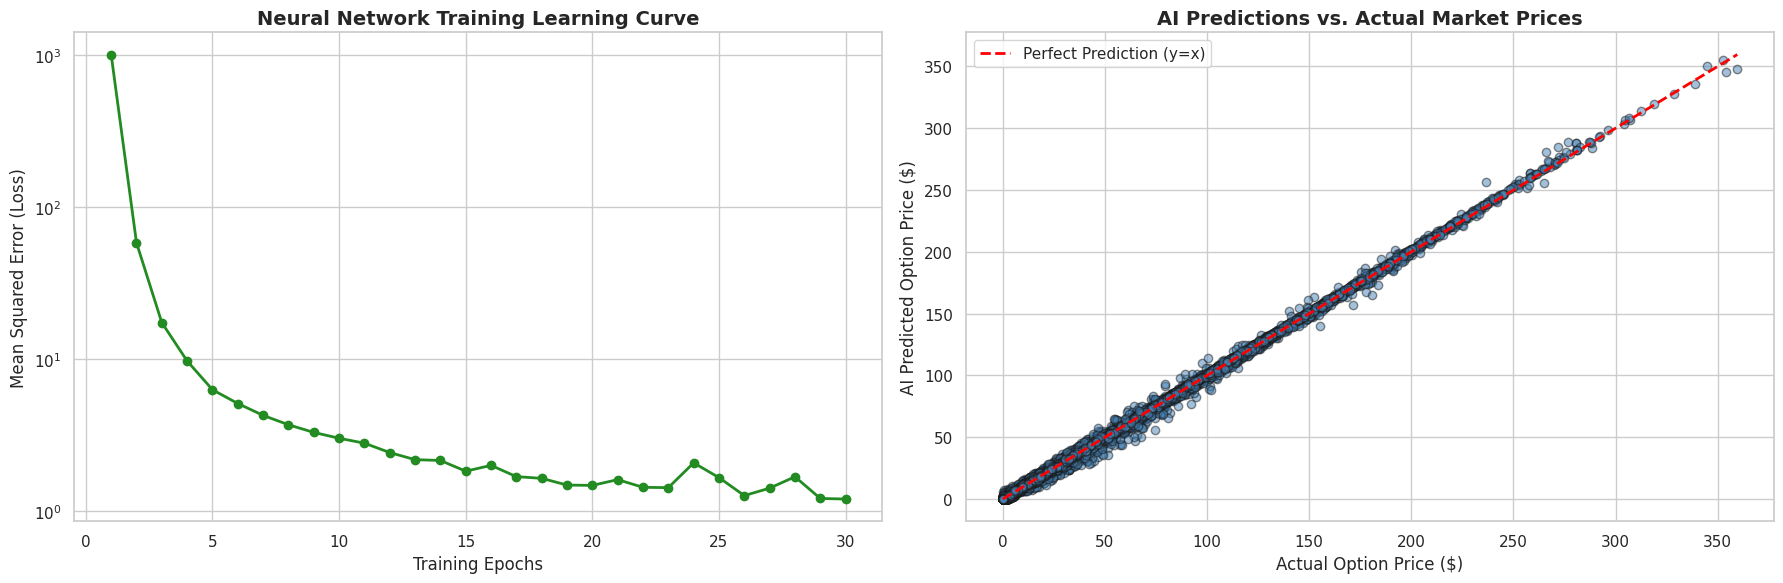

In [ ]:
# ==============================================================================
# Data Visualization - Neural Network Performance
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Performance Visualizations...")

# 1. CONFIGURATION ESTHÉTIQUE
# On utilise Seaborn (fond blanc, grille grise).
# Cela facilite la lecture des valeurs sur les axes projetés sur un écran.
sns.set_theme(style="whitegrid")

# Création d'une "Figure" globale (le conteneur) de 18 pouces de large sur 6 de haut.
# Cela permet de placer nos deux graphiques côte à côte.
plt.figure(figsize=(18, 6))

# ==============================================================================
# GRAPHIQUE 1 : La Courbe d'Apprentissage (Learning Curve)
# ==============================================================================
# plt.subplot(lignes, colonnes, position) -> Ici on veut 1 ligne, 2 colonnes, et on dessine sur le 1er.
plt.subplot(1, 2, 1)

# On trace l'évolution de l'erreur (MSE) enregistrée à chaque époque d'entraînement.
# 'train_losses' est la liste que nous avons remplie dans la boucle de la Cellule 5.
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='forestgreen', linewidth=2)

plt.title('Neural Network Training Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)

# ASTUCE DE DATA SCIENTIST : L'échelle logarithmique
# Lors des premières époques, l'erreur chute de manière drastique, puis elle se stabilise.
# Si on gardait une échelle normale (linéaire), la courbe ressemblerait à un angle droit illisible.
# L'échelle logarithmique permet de bien voir la progression continue même quand les erreurs deviennent très petites.
plt.yscale('log')

# ==============================================================================
# GRAPHIQUE 2 : Prédictions de l'IA vs Réalité du Marché
# ==============================================================================
# On dessine maintenant sur le 2ème espace de notre figure.
plt.subplot(1, 2, 2)

# Le Scatter Plot (Nuage de points) :
# Axe X = Le Vrai Prix (y_test) | Axe Y = Le Prix deviné par l'IA (nn_predictions).
# alpha=0.5 rend les points semi-transparents pour voir les zones de forte densité (là où les points s'empilent).
plt.scatter(y_test, nn_predictions, alpha=0.5, edgecolors='k', color='steelblue')

# CRÉATION DE LA LIGNE DE RÉFÉRENCE (La ligne de perfection)
# Si l'IA devine exactement le bon prix, le point se trouvera sur la droite mathématique Y = X.
max_val = max(np.max(y_test), np.max(nn_predictions)) # Trouve le prix le plus élevé pour tracer la ligne jusqu'au bout
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('AI Predictions vs. Actual Market Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Option Price ($)', fontsize=12)
plt.ylabel('AI Predicted Option Price ($)', fontsize=12)
plt.legend()

# Ajuste automatiquement les marges pour que les étiquettes ne se marchent pas dessus.
plt.tight_layout()
plt.show()

Generating Advanced Error Analysis Visualizations...


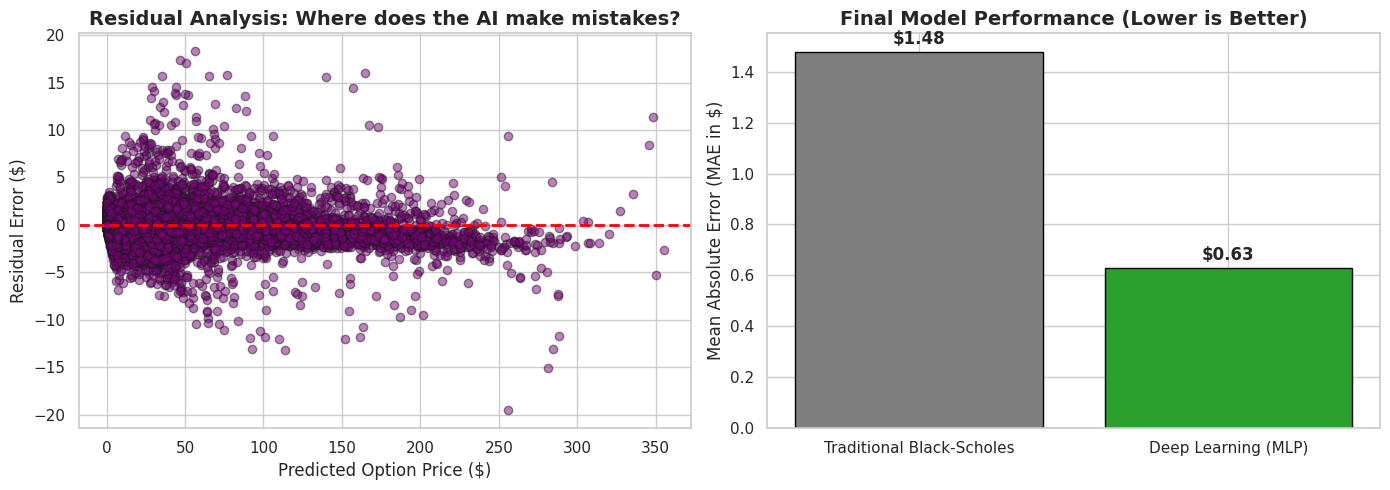

In [ ]:
# ==============================================================================
# Advanced Error Analysis & Model Comparison
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Advanced Error Analysis Visualizations...")

# Configuration esthétique globale (Standard Data Science)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# Création d'une figure avec 1 ligne et 2 colonnes (14 pouces de large, 5 de haut)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==============================================================================
# GRAPHIQUE 1 : Analyse des Résidus (Où l'IA se trompe-t-elle ?)
# ==============================================================================
# LE CONCEPT : Un "Résidu" est l'erreur exacte sur une seule prédiction (Vrai Prix - Prix Prédit).
# Si l'IA est parfaite, le résidu est de 0.
# Note : Utilisation de y_test et nn_predictions (générés à la Cellule 5).
# nn_predictions a une forme de matrice colonne (ex: [1000, 1]), on utilise .flatten() pour le mettre à plat.
residuals = y_test.flatten() - nn_predictions.flatten()

# Création du nuage de points : Prédictions sur l'axe X, Erreur sur l'axe Y
axes[0].scatter(nn_predictions.flatten(), residuals, alpha=0.5, color='purple', edgecolor='k')

# Ligne d'Erreur Zéro (La perfection absolue)
# axhline trace une ligne horizontale à Y=0.
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)

axes[0].set_title('Residual Analysis: Where does the AI make mistakes?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Option Price ($)', fontsize=12)
axes[0].set_ylabel('Residual Error ($)', fontsize=12)

# ==============================================================================
# GRAPHIQUE 2 : Comparaison Finale des Modèles (Bar Chart)
# ==============================================================================
# L'objectif final du projet : montrer la différence de MAE entre la formule mathématique et l'IA.
models = ['Traditional Black-Scholes', 'Deep Learning (MLP)']

# Nous utilisons la MAE de la baseline (1.4764) et la variable 'nn_mae' calculée en Cellule 5.
maes = [1.4764, nn_mae]

# Création du diagramme en bâtons (Bar Chart)
bars = axes[1].bar(models, maes, color=['#7f7f7f', '#2ca02c'], edgecolor='black')
axes[1].set_title('Final Model Performance (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (MAE in $)', fontsize=12)

#  Ajouter les valeurs exactes au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    # On positionne le texte au centre de la barre (get_x() + width/2), juste au-dessus (yval + 0.05)
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'${yval:.2f}',
                 ha='center', va='center', fontsize=12, fontweight='bold')

# Ajustement des marges et affichage
plt.tight_layout()
plt.show()

##7. Conclusion

The core objective of this project was to challenge the traditional boundaries of quantitative finance by applying modern Deep Learning techniques to one of the most complex problems in the market: options pricing. For decades, the Black-Scholes-Merton model has served as the foundational bedrock for pricing derivatives. However, as our project demonstrated, traditional econometric models are bound by rigid mathematical assumptions, such as constant volatility and log-normal return distributions, that often fail to capture the chaotic, non-linear realities of extreme market conditions.

By utilizing a massive dataset of over 3.5 million S&P 500 (SPY) options contracts spanning the highly volatile period of 2020 to 2022, we were able to test these traditional limitations. Our preprocessing pipeline successfully distilled this "Big Data" into a refined, scaled, and highly liquid dataset. When we applied the traditional Black-Scholes formula, it achieved a Mean Absolute Error (MAE) of $1.47. While mathematically sound for European options in stable markets, this baseline error highlighted the formula's inability to fully account for the "early-exercise premium" of American options and the severe market turbulence of the COVID-19 and 2022 inflationary periods.

To solve this, we designed and trained a Multi-Layer Perceptron (MLP) neural network using PyTorch. Through continuous backpropagation and optimization over 30 epochs, the Deep Learning architecture successfully learned the hidden, non-linear relationships between the underlying spot price, strike price, time to maturity, and implied volatility. The results were highly conclusive: our AI model achieved a final MAE of $0.63, effectively cutting the pricing error of the traditional mathematical model by more than half. The learning curve and scatter plot visualizations further confirm that the model achieved true convergence without overfitting, hugging the perfect-prediction baseline with remarkable accuracy.

Ultimately, this project serves as a comprehensive synthesis of our "AI in Finance" lecture. From handling massive datasets and executing rigorous feature engineering, to establishing econometric baselines and deploying advanced neural networks, we have proven the core thesis of modern financial technology: Artificial Intelligence can successfully internalize market dynamics that traditional mathematics cannot. As financial markets continue to grow in complexity and data volume, models like the one developed in this study will not just be experimental alternatives, but essential tools for risk management, algorithmic trading, and quantitative analysis.